In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"Student Performance.csv")

In [4]:
df.head()

,Roll No,Student Name,English,Tamil,Maths,Science,Total Marks,Result
0,R001,Akshaya,77,92,36,97,302,Pass
1,R002,Neena,93,89,90,42,314,Pass
2,R003,Dhanya,95,56,58,72,281,Pass
3,R004,Aswini,69,98,79,77,323,Pass
4,R005,Shakina,45,74,35,37,191,Pass


In [5]:
df.shape

(500, 8)

In [6]:
df.columns

Index(['Roll No', 'Student Name', 'English', 'Tamil', 'Maths', 'Science',
       'Total Marks', 'Result'],
      dtype='object')

In [7]:
df.dtypes

,0
Roll No,object
Student Name,object
English,int64
Tamil,int64
Maths,int64
Science,int64
Total Marks,int64
Result,object


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Roll No       500 non-null    object
 1   Student Name  500 non-null    object
 2   English       500 non-null    int64 
 3   Tamil         500 non-null    int64 
 4   Maths         500 non-null    int64 
 5   Science       500 non-null    int64 
 6   Total Marks   500 non-null    int64 
 7   Result        500 non-null    object
dtypes: int64(5), object(3)
memory usage: 31.4+ KB


In [9]:
df.replace(r'^\s*$',np.nan,regex=True,inplace=True)
df.isnull()
df.head()

,Roll No,Student Name,English,Tamil,Maths,Science,Total Marks,Result
0,R001,Akshaya,77,92,36,97,302,Pass
1,R002,Neena,93,89,90,42,314,Pass
2,R003,Dhanya,95,56,58,72,281,Pass
3,R004,Aswini,69,98,79,77,323,Pass
4,R005,Shakina,45,74,35,37,191,Pass


In [10]:
df.isnull().sum()

,0
Roll No,0
Student Name,0
English,0
Tamil,0
Maths,0
Science,0
Total Marks,0
Result,0


In [11]:
subjects = ['English', 'Tamil', 'Maths', 'Science']

# Average
df['Average'] = df[subjects].mean(axis=1)

# Grade Function
def grade(avg):
    if avg >= 90:
        return 'A+'
    elif avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Average'].apply(grade)

# Pass/Fail
df['Status'] = df['Average'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')

print(df)

    Roll No Student Name  English  Tamil  Maths  Science  Total Marks Result  \
0      R001      Akshaya       77     92     36       97          302   Pass   
1      R002        Neena       93     89     90       42          314   Pass   
2      R003       Dhanya       95     56     58       72          281   Pass   
3      R004       Aswini       69     98     79       77          323   Pass   
4      R005      Shakina       45     74     35       37          191   Pass   
..      ...          ...      ...    ...    ...      ...          ...    ...   
495    R496      Arjun T       39     35     83       48          205   Pass   
496    R497      Rahul M       82     86     39       62          269   Pass   
497    R498    Keerthi V       92     49     37       83          261   Pass   
498    R499   Aadhya Raj       56     84     39       38          217   Pass   
499    R500     Vikram K       35     41     99       57          232   Pass   

     Average Grade Status  
0      75.5

In [12]:
subject_average = df[subjects].mean()

print("\nSubject-wise Average Marks")
print(subject_average)


Subject-wise Average Marks
English    67.602
Tamil      66.866
Maths      68.270
Science    66.122
dtype: float64


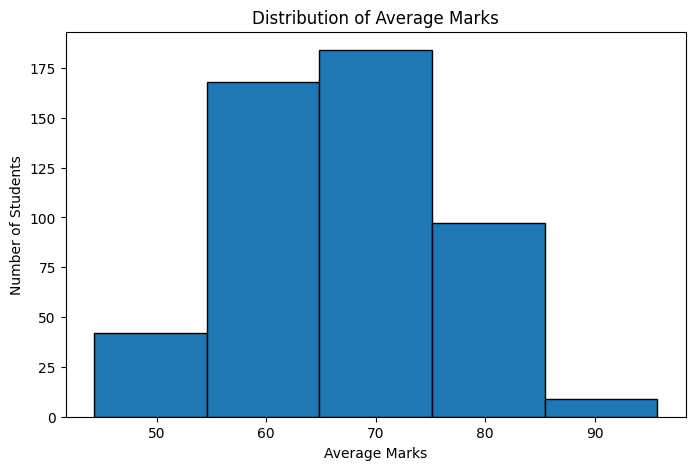

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df['Average'], bins=5, edgecolor='black')
plt.title("Distribution of Average Marks")
plt.xlabel("Average Marks")
plt.ylabel("Number of Students")
plt.show()

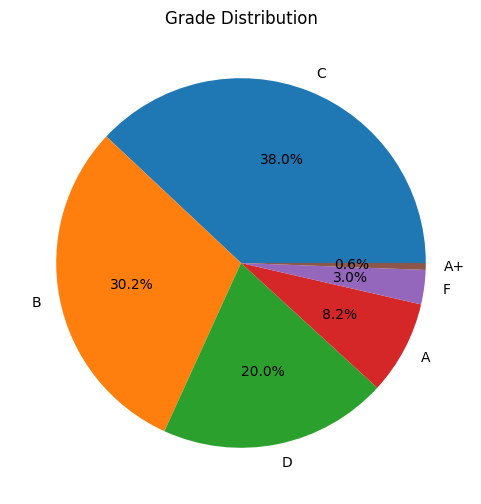

In [14]:
plt.figure(figsize=(6,6))
df['Grade'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Grade Distribution")
plt.ylabel("")
plt.show()

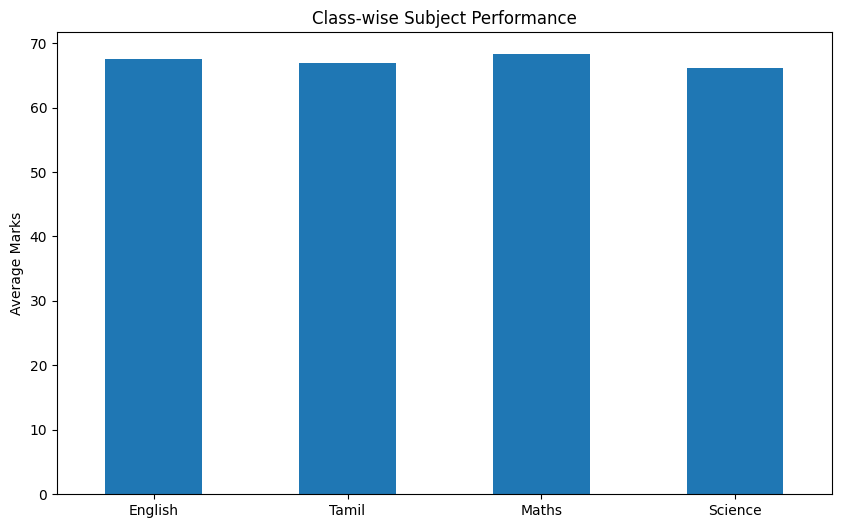

In [16]:
class_result = df[subjects].mean()
class_result.plot(kind='bar', figsize=(10,6))
plt.title("Class-wise Subject Performance")
plt.ylabel("Average Marks")
plt.xticks(rotation=0)
plt.show()

In [22]:
class_result = df.groupby("Grade").agg(
    Students=("Student Name", "count"),
    Average_Marks=("Average", "mean"),
    Highest_Marks=("Average", "max"),
    Lowest_Marks=("Average", "min"),
    Pass_Count=("Status", lambda x: (x == "Pass").sum()),
    Fail_Count=("Status", lambda x: (x == "Fail").sum())
)
display(class_result)

,Students,Average_Marks,Highest_Marks,Lowest_Marks,Pass_Count,Fail_Count
Grade,,,,,,
A,41,83.164634,89.50,80.00,41,0
A+,3,92.916667,95.75,90.25,3,0
B,151,74.514901,79.75,70.00,151,0
C,190,64.885526,69.75,60.00,190,0
D,100,56.325000,59.75,50.00,100,0
F,15,47.100000,49.00,44.25,15,0
